# Model Performance Analysis

이 노트북은 학습된 `sign_language_gru.pth` 모델의 성능을 여러 각도에서 분석하고 시각화하는 그래프를 생성합니다.

In [25]:
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

# 한글 폰트 설정 (Windows 기본 폰트인 맑은 고딕 사용)
plt.rc('font', family='Malgun Gothic')
plt.rc('axes', unicode_minus=False)

import sys
sys.path.append('.')
from modules.models import SignLanguageModel

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

### 1. 데이터 및 모델 로드

In [26]:
DATA_DIR = "data/processed"

# Load mappings
with open(os.path.join(DATA_DIR, "core_label_map.json"), "r", encoding="utf-8") as f:
    label_map = json.load(f)
    num_classes = len(label_map)

with open(os.path.join(DATA_DIR, "core_ksl_word_dictionary.json"), "r", encoding="utf-8") as f:
    korean_dict = json.load(f)

idx_to_label = {idx: korean_dict.get(key, key) for key, idx in label_map.items()}

with open(os.path.join(DATA_DIR, "core_category_map.json"), "r", encoding="utf-8") as f:
    category_map = json.load(f)["categories"]

# Load Model
model = SignLanguageModel(num_classes=num_classes).to(device)
model_path = "models/sign_language_gru.pth"
if os.path.exists(model_path):
    model.load_state_dict(torch.load(model_path, map_location=device))
    print("Model loaded successfully!")
else:
    print("Model file not found!")
model.eval()

# Load Data & Split (same random_state=42 as training to get the validation set)
X_train_raw = np.load(os.path.join(DATA_DIR, "X_train.npy"))
y_train_raw = np.load(os.path.join(DATA_DIR, "y_train.npy"))
_, X_val, _, y_val = train_test_split(X_train_raw, y_train_raw, test_size=0.1, random_state=42, stratify=y_train_raw)
print(f"Validation Set Size: {len(X_val)} samples")

Model loaded successfully!
Validation Set Size: 560 samples


### 2. 검증 데이터셋(Validation Set) 추론

In [27]:
all_preds_top1 = []
all_preds_top3 = []
all_preds_top5 = []
all_labels = []

with torch.no_grad():
    # Batch processing to avoid memory issues
    batch_size = 64
    for i in range(0, len(X_val), batch_size):
        X_batch = torch.FloatTensor(X_val[i:i+batch_size]).to(device)
        y_batch = y_val[i:i+batch_size]
        
        logits = model(X_batch)
        probs = torch.softmax(logits, dim=1)
        
        _, top5_idx = torch.topk(probs, 5, dim=1)
        top5_idx = top5_idx.cpu().numpy()
        
        for j in range(len(y_batch)):
            all_labels.append(y_batch[j])
            all_preds_top1.append(top5_idx[j][0])
            all_preds_top3.append(top5_idx[j][:3])
            all_preds_top5.append(top5_idx[j])

all_labels = np.array(all_labels)
all_preds_top1 = np.array(all_preds_top1)

### 3. Top-K 정확도 그래프
모델이 1순위, 3순위, 5순위 안에 정답을 맞출 확률을 보여줍니다.

C:\Users\sejee\AppData\Local\Temp\ipykernel_21784\334670218.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=['Top-1', 'Top-3', 'Top-5'], y=[top1_acc, top3_acc, top5_acc], palette='viridis')


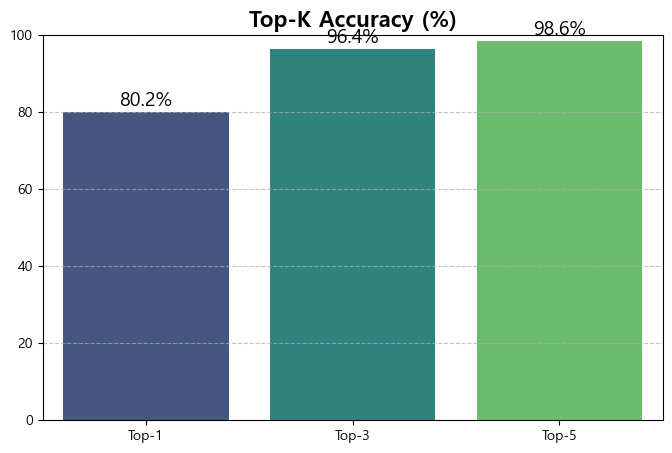

In [28]:
top1_acc = np.mean(all_preds_top1 == all_labels) * 100
top3_acc = np.mean([all_labels[i] in all_preds_top3[i] for i in range(len(all_labels))]) * 100
top5_acc = np.mean([all_labels[i] in all_preds_top5[i] for i in range(len(all_labels))]) * 100

plt.figure(figsize=(8, 5))
sns.barplot(x=['Top-1', 'Top-3', 'Top-5'], y=[top1_acc, top3_acc, top5_acc], palette='viridis')
plt.title('Top-K Accuracy (%)', fontsize=16, fontweight='bold')
plt.ylim(0, 100)
for i, val in enumerate([top1_acc, top3_acc, top5_acc]):
    plt.text(i, val + 1.5, f'{val:.1f}%', ha='center', fontsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### 4. 카테고리별 정확도 (Category-wise Accuracy)
어느 카테고리(예: 인사, 행동, 음식)에서 모델이 취약한지 파악할 수 있습니다.

C:\Users\sejee\AppData\Local\Temp\ipykernel_21784\3858366776.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cat_accs, y=cat_names, palette='coolwarm')


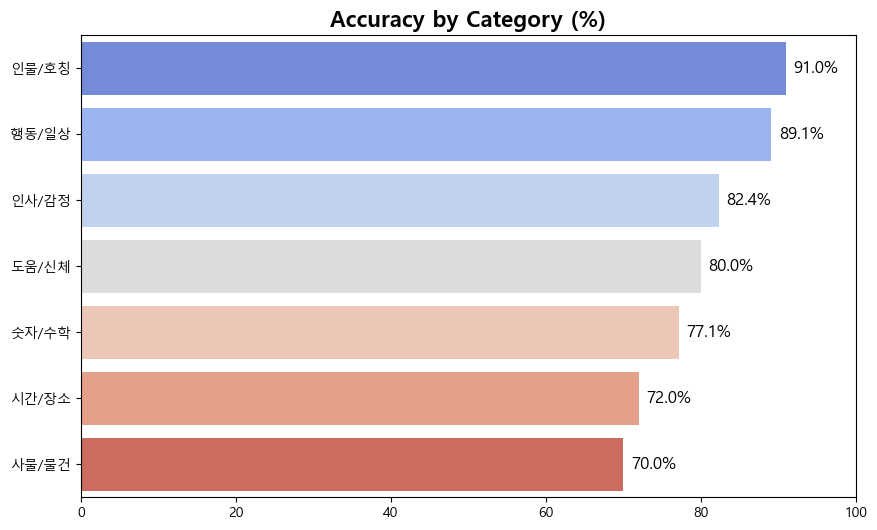

In [29]:
category_acc = {}
for cat in category_map:
    indices = cat['indices']
    # Find validation samples belonging to this category
    cat_mask = np.isin(all_labels, indices)
    if np.sum(cat_mask) > 0:
        acc = np.mean(all_preds_top1[cat_mask] == all_labels[cat_mask]) * 100
        category_acc[cat['name']] = acc

cat_names = list(category_acc.keys())
cat_accs = list(category_acc.values())

# Sort by accuracy descending
sorted_indices = np.argsort(cat_accs)[::-1]
cat_names = [cat_names[i] for i in sorted_indices]
cat_accs = [cat_accs[i] for i in sorted_indices]

plt.figure(figsize=(10, 6))
sns.barplot(x=cat_accs, y=cat_names, palette='coolwarm')
plt.title('Accuracy by Category (%)', fontsize=16, fontweight='bold')
plt.xlim(0, 100)
for i, val in enumerate(cat_accs):
    plt.text(val + 1, i, f'{val:.1f}%', va='center', fontsize=12)
plt.show()

### 5. 최우수 및 최악의 단어 Top 10
모델이 거의 완벽하게 맞추는 단어 10개와, 유독 헷갈려하는 단어 10개를 시각화합니다.

C:\Users\sejee\AppData\Local\Temp\ipykernel_21784\3507998594.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=[val for _, val in best_10], y=[name for name, _ in best_10], ax=axes[0], palette='Greens_r')
C:\Users\sejee\AppData\Local\Temp\ipykernel_21784\3507998594.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=[val for _, val in worst_10], y=[name for name, _ in worst_10], ax=axes[1], palette='Reds_r')


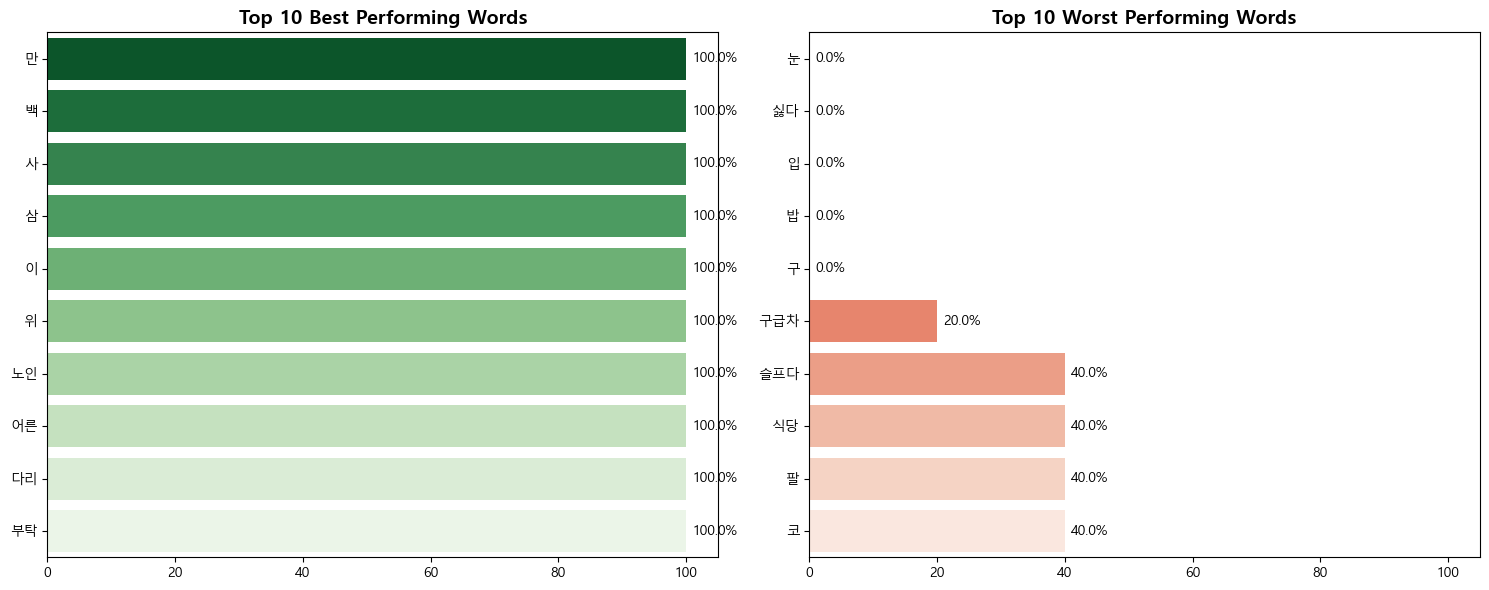

In [30]:
word_acc = {}
for cls_idx in range(num_classes):
    mask = (all_labels == cls_idx)
    if np.sum(mask) > 0:
        word_acc[idx_to_label[cls_idx]] = np.mean(all_preds_top1[mask] == all_labels[mask]) * 100

sorted_words = sorted(word_acc.items(), key=lambda item: item[1])

worst_10 = sorted_words[:10]
best_10 = sorted_words[-10:][::-1]  # reverse to show absolute best at top

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sns.barplot(x=[val for _, val in best_10], y=[name for name, _ in best_10], ax=axes[0], palette='Greens_r')
axes[0].set_title('Top 10 Best Performing Words', fontsize=14, fontweight='bold')
axes[0].set_xlim(0, 105)
for i, val in enumerate([val for _, val in best_10]):
    axes[0].text(val + 1, i, f'{val:.1f}%', va='center')

sns.barplot(x=[val for _, val in worst_10], y=[name for name, _ in worst_10], ax=axes[1], palette='Reds_r')
axes[1].set_title('Top 10 Worst Performing Words', fontsize=14, fontweight='bold')
axes[1].set_xlim(0, 105)
for i, val in enumerate([val for _, val in worst_10]):
    axes[1].text(val + 1, i, f'{val:.1f}%', va='center')

plt.tight_layout()
plt.show()

### 6. 훈련 손실(Loss) 및 정확도(Accuracy) 추이
`GRU_Model_Training.ipynb`에서 학습 시 저장된 `training_history.json`을 불러와 모델의 학습 곡선을 그립니다. 과적합 여부를 파악하기 좋습니다.

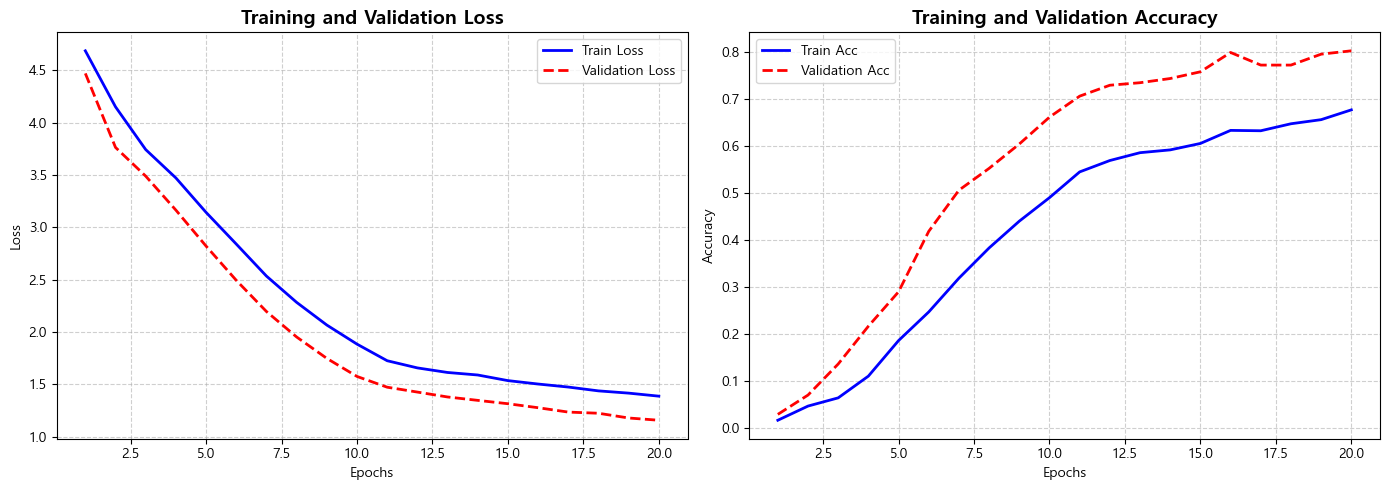

In [31]:
history_path = "models/training_history.json"
if os.path.exists(history_path):
    with open(history_path, "r", encoding="utf-8") as f:
        history = json.load(f)
    
    epochs = range(1, len(history['train_loss']) + 1)
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    # Loss Plot
    ax1.plot(epochs, history['train_loss'], 'b-', label='Train Loss', linewidth=2)
    ax1.plot(epochs, history['val_loss'], 'r--', label='Validation Loss', linewidth=2)
    ax1.set_title('Training and Validation Loss', fontsize=14, fontweight='bold')
    ax1.set_xlabel('Epochs')
    ax1.set_ylabel('Loss')
    ax1.legend()
    ax1.grid(True, linestyle='--', alpha=0.6)
    
    # Accuracy Plot
    ax2.plot(epochs, history['train_acc'], 'b-', label='Train Acc', linewidth=2)
    ax2.plot(epochs, history['val_acc'], 'r--', label='Validation Acc', linewidth=2)
    ax2.set_title('Training and Validation Accuracy', fontsize=14, fontweight='bold')
    ax2.set_xlabel('Epochs')
    ax2.set_ylabel('Accuracy')
    ax2.legend()
    ax2.grid(True, linestyle='--', alpha=0.6)
    
    plt.tight_layout()
    plt.show()
else:
    print("training_history.json 파일이 없습니다. GRU_Model_Training.ipynb를 먼저 실행하여 학습을 완료해주세요.")

### 7. 종합 성능 리포트 (Classification Report)
전체적인 Precision, Recall, F1-Score를 표 형식으로 확인합니다.

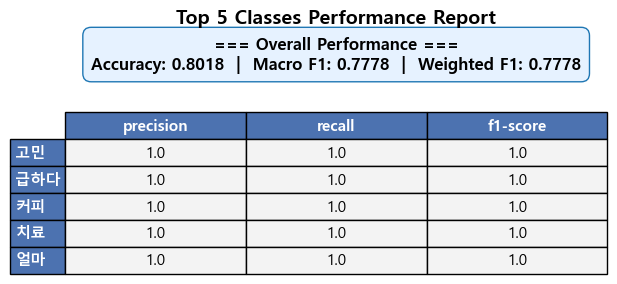

In [32]:
import pandas as pd
import matplotlib.pyplot as plt

report = classification_report(all_labels, all_preds_top1, output_dict=True, zero_division=0)
df_report = pd.DataFrame(report).transpose()

# 1. 종합 성능 요약 텍스트 준비
acc = df_report.loc['accuracy', 'f1-score']
macro_f1 = df_report.loc['macro avg', 'f1-score']
weighted_f1 = df_report.loc['weighted avg', 'f1-score']
summary_text = f"=== Overall Performance ===\nAccuracy: {acc:.4f}  |  Macro F1: {macro_f1:.4f}  |  Weighted F1: {weighted_f1:.4f}"

# 2. 상위 5개 클래스만 추출 (테이블용 데이터)
class_df = df_report.iloc[:-3].copy()
class_df.index = [idx_to_label.get(int(idx), idx) for idx in class_df.index]
class_df_sorted = class_df.sort_values(by='f1-score', ascending=False).head(5)
table_data = class_df_sorted[['precision', 'recall', 'f1-score']].round(3)

# 3. 하나의 이미지에 요약 텍스트와 테이블 함께 그리기
fig, ax = plt.subplots(figsize=(7, 3)) # 크기와 여백 대폭 축소
ax.axis('off') # 그래프 축 숨기기

# 요약 텍스트 상단 배치
plt.text(0.5, 0.95, summary_text, ha='center', va='center', fontsize=12, fontweight='bold', 
         bbox=dict(boxstyle='round,pad=0.5', facecolor='#e6f2ff', edgecolor='#1f77b4'))

# 테이블 하단 배치 (보더라인 포함)
table = ax.table(cellText=table_data.values,
                 rowLabels=table_data.index,
                 colLabels=table_data.columns,
                 cellLoc='center', 
                 loc='center',
                 bbox=[0, 0, 1, 0.7]) # [left, bottom, width, height]

table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1, 1.5)

# 테이블 헤더 및 행 이름 스타일링 (색상 및 굵게)
for (row, col), cell in table.get_celld().items():
    if row == 0 or col == -1:
        cell.set_text_props(fontweight='bold', color='white')
        cell.set_facecolor('#4c72b0')
    else:
        cell.set_facecolor('#f3f3f3')
    cell.set_edgecolor('black') # 테두리선(보더라인) 명확하게 추가

plt.title('Top 5 Classes Performance Report', fontsize=14, fontweight='bold', y=1.05)
plt.show()
